In [1]:
!pip install kiwipiepy scikit-learn matplotlib pandas openpyxl

In [2]:
import sys
!{sys.executable} -m pip install kiwipiepy


  Using cached kiwipiepy-0.23.1-cp39-abi3-macosx_11_0_arm64.whl.metadata (1.1 kB)
  Using cached kiwipiepy_model-0.23.0.tar.gz (88.0 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Using cached kiwipiepy-0.23.1-cp39-abi3-macosx_11_0_arm64.whl (4.1 MB)
  Created wheel for kiwipiepy-model: filename=kiwipiepy_model-0.23.0-py3-none-any.whl size=88067872 sha256=90f91cd13f9bacccbca4ac229a47d6f637529b0b9bdf8fe2f96e578681c8886b
  Stored in directory: /Users/minhee/Library/Caches/pip/wheels/fc/ec/dc/d68011c689884787df7fdf519d42df546053c4d77eedbdc789
Successfully built kiwipiepy-model
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [kiwipiepy]model]

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip3.14 install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
from kiwipiepy import Kiwi
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정 (Windows: malgun, Mac: AppleGothic, Linux: NanumGothic)
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # Mac
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    # NanumGothic이 설치된 경우
    font_path = None
    for f in fm.findSystemFonts():
        if any(k in f.lower() for k in ['nanum', 'gothic', 'notosans']):
            font_path = f
            break
    if font_path:
        fm.fontManager.addfont(font_path)
        plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()

plt.rcParams['axes.unicode_minus'] = False
print('설정 완료')

설정 완료


In [4]:
FILE_PATH = '/Users/minhee/Desktop/DB/데이터_수집/관광데이터_합본.xlsx'

df = pd.read_excel(FILE_PATH)
print(f'총 데이터 수: {len(df)}')
print(f'컬럼: {list(df.columns)}')
df.head(3)

총 데이터 수: 4008
컬럼: ['source', 'name', 'description', 'image_url', 'lat', 'lng', 'address', '주제분류', '주소', '분류', '원문URL', 'category', 'cat1']


,source,name,description,image_url,lat,lng,address,주제분류,주소,분류,원문URL,category,cat1
0,명소,경복궁,경복궁은 조선 시대에 지어진 왕궁 중 가장 큰 궁궐이었습니다. 조선 왕조 개국 3년...,https://korean.visitseoul.net/data/POST/201712...,37.583307,126.977286,사직로 161,NaN,NaN,NaN,NaN,NaN,NaN
1,명소,남산서울타워,도심 속 로맨틱 아일랜드로 입지를 굳힌 남산서울타워는 예로부터 백년해로의 길지로 널...,https://korean.visitseoul.net/data/MEDIA/20251...,37.551174,126.988019,남산공원길 105,NaN,NaN,NaN,NaN,NaN,NaN
2,명소,익선동 한옥거리,"서울 익선동은 1920년대 한옥이 아름답게 보존된 골목 사이로 트렌디한 카페, 개성...",https://korean.visitseoul.net/data/MEDIA/20240...,37.5739,126.989700,수표로28길 33-3,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# description 결측치 제거
DESC_COL = 'description'
df = df.dropna(subset=[DESC_COL]).reset_index(drop=True)
print(f'description 있는 데이터 수: {len(df)}')

description 있는 데이터 수: 4005


## 3. 한국어 형태소 분석 — 명사 추출
kiwipiepy로 각 description에서 명사(N*)만 추출합니다.

In [6]:
kiwi = Kiwi()

def extract_nouns(text):
    """텍스트에서 2글자 이상 명사만 추출해 공백으로 연결"""
    try:
        result = kiwi.analyze(str(text))
        tokens = result[0][0]
        nouns = [t.form for t in tokens if t.tag.startswith('N') and len(t.form) > 1]
        return ' '.join(nouns)
    except:
        return ''

print('형태소 분석 중... (데이터 수에 따라 수 분 소요)')
df['nouns'] = df[DESC_COL].apply(extract_nouns)
print('완료!')

# 샘플 확인
print('\n[샘플]')
print('원문:', df[DESC_COL].iloc[0][:80], '...')
print('명사:', df['nouns'].iloc[0][:80], '...')

형태소 분석 중... (데이터 수에 따라 수 분 소요)
완료!

[샘플]
원문: 경복궁은 조선 시대에 지어진 왕궁 중 가장 큰 궁궐이었습니다. 조선 왕조 개국 3년인 1395년에 창건된 궁궐은 390여 칸으로 한양의 중심축에 ...
명사: 경복궁 조선 시대 왕궁 궁궐 조선 왕조 개국 창건 궁궐 한양 중심축 자리 개국 공신 정도전 태조 궁궐 이름 고심 왕조 번영 의미 경복궁 이름 조 ...


## 4. TF-IDF 벡터화

In [7]:
# max_features: 사용할 단어 수 (많을수록 정밀하지만 느림)
# min_df: 최소 2개 문서에 등장한 단어만 사용
vectorizer = TfidfVectorizer(max_features=300, min_df=2)
X = vectorizer.fit_transform(df['nouns'])
print(f'TF-IDF 행렬 크기: {X.shape}  →  (문서 수, 단어 수)')

TF-IDF 행렬 크기: (4005, 300)  →  (문서 수, 단어 수)


## 5. 최적 클러스터 수 탐색 — 실루엣 점수

In [8]:
# k 범위 설정 (탐색 범위를 넓히면 더 오래 걸림)
K_MIN, K_MAX = 4, 12

silhouette_scores = []
k_range = range(K_MIN, K_MAX + 1)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)
    print(f'  k={k:2d}: 실루엣 점수 = {score:.4f}')

best_k = list(k_range)[np.argmax(silhouette_scores)]
print(f'\n✅ 최적 k = {best_k}  (실루엣 점수: {max(silhouette_scores):.4f})')

  k= 4: 실루엣 점수 = 0.0296
  k= 5: 실루엣 점수 = 0.0336
  k= 6: 실루엣 점수 = 0.0354
  k= 7: 실루엣 점수 = 0.0396
  k= 8: 실루엣 점수 = 0.0421
  k= 9: 실루엣 점수 = 0.0463
  k=10: 실루엣 점수 = 0.0476
  k=11: 실루엣 점수 = 0.0483
  k=12: 실루엣 점수 = 0.0502

✅ 최적 k = 12  (실루엣 점수: 0.0502)


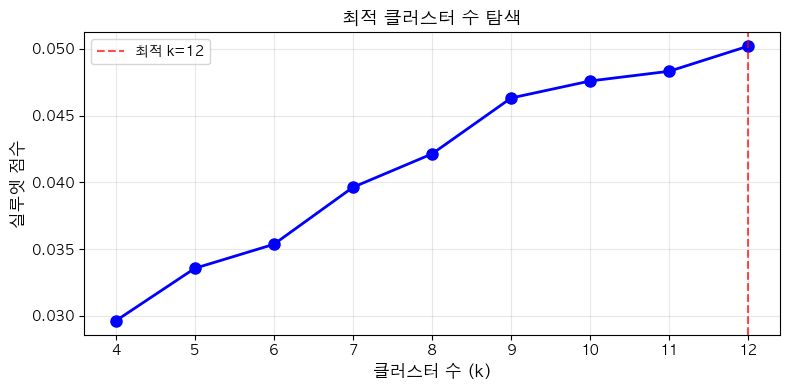

In [9]:
# 실루엣 점수 시각화
plt.figure(figsize=(8, 4))
plt.plot(list(k_range), silhouette_scores, 'bo-', linewidth=2, markersize=8)
plt.axvline(x=best_k, color='red', linestyle='--', alpha=0.7, label=f'최적 k={best_k}')
plt.xlabel('클러스터 수 (k)', fontsize=12)
plt.ylabel('실루엣 점수', fontsize=12)
plt.title('최적 클러스터 수 탐색', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. 최적 k로 클러스터링

In [10]:
# best_k 대신 직접 숫자를 지정할 수도 있음
# best_k = 8

km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['cluster'] = km_final.fit_predict(X)
print(f'클러스터링 완료: {best_k}개 그룹')
print(df['cluster'].value_counts().sort_index())

클러스터링 완료: 12개 그룹
cluster
0      281
1      255
2      225
3      106
4      194
5      156
6     1167
7      496
8      251
9      402
10     335
11     137
Name: count, dtype: int64


## 7. 클러스터별 주요 키워드 확인

In [11]:
feature_names = vectorizer.get_feature_names_out()
cluster_keywords = {}

print('=== 클러스터별 주요 키워드 및 명소 ===')
for i in range(best_k):
    # 클러스터 중심 벡터에서 상위 키워드 추출
    center = km_final.cluster_centers_[i]
    top_idx = center.argsort()[-10:][::-1]
    keywords = [feature_names[j] for j in top_idx]
    cluster_keywords[i] = keywords
    
    items = df[df['cluster'] == i]['name'].tolist()
    print(f'\n[클러스터 {i}] ({len(items)}개)')
    print(f'  키워드: {" | ".join(keywords)}')
    print(f'  명소 예시: {", ".join(items[:6])}')

=== 클러스터별 주요 키워드 및 명소 ===

[클러스터 0] (281개)
  키워드: 작가 | 미술 | 갤러리 | 전시 | 작품 | 미술관 | 현대 | 예술 | 한국 | 아트
  명소 예시: 서울시립미술관 (서소문본관), 리움 미술관, 송은(SONGEUN), 갤러리 현대, 아모레퍼시픽미술관, 겸재정선미술관

[클러스터 1] (255개)
  키워드: 공연 | 공연장 | 극장 | 무대 | 공간 | 음향 | 예술 | 연극 | 규모 | 문화
  명소 예시: 소극장 산울림, 씨어터쿰, 노원문화예술회관, 동숭무대소극장, 한국방송회관 코바코홀, 갈산문화예술센터

[클러스터 2] (225개)
  키워드: 박물관 | 전시 | 역사 | 유물 | 문화 | 전시실 | 교육 | 개관 | 수집 | 한국
  명소 예시: 국립중앙박물관, 한국가구박물관, 대한민국역사박물관, 서울역사박물관, 서대문자연사박물관, 피규어뮤지엄W

[클러스터 3] (106개)
  키워드: 한강 | 공원 | 서울 | 조명 | 공간 | 연결 | 명소 | 위치 | 문화 | 시설
  명소 예시: 한강 이랜드크루즈, 세빛섬, 한강버스, 풍납토성, 살곶이다리（전곶교）, 잠실대교

[클러스터 4] (194개)
  키워드: 도서관 | 자료실 | 독서 | 정보 | 문화 | 어린이 | 지역 | 주민 | 도서 | 공간
  명소 예시: 별마당 도서관, 서울도서관 (옛 서울시청사), 정독도서관, 국립중앙도서관, 김근태기념도서관, 손기정문화도서관

[클러스터 5] (156개)
  키워드: 호텔 | 객실 | 비즈니스 | 서비스 | 서울 | 고객 | 위치 | 제공 | 시설 | 편리
  명소 예시: 서울중앙우체국, 수락휴 트리하우스, 포포인츠 바이 쉐라톤 서울 구로, 롯데호텔 월드, 켄싱턴호텔 여의도 (구. 렉싱턴호텔), 나이아가라 호텔

[클러스터 6] (1167개)
  키워드: 공간 | 다양 | 체험 | 운영 | 서울 | 한국 | 거리 | 시설 | 위치 | 전통
  명소 예시: 익선동 한옥거리, 롯데월드타워, 63스퀘어, 북촌한옥마을,

## 8. 시각화

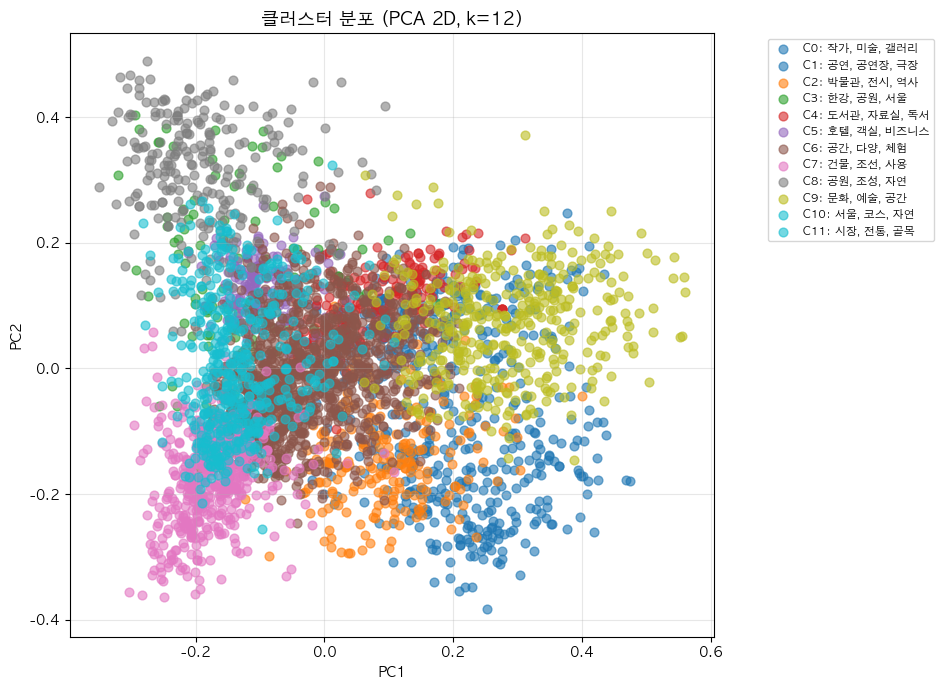

In [12]:
# PCA로 2D 축소 후 클러스터 분포 시각화
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X.toarray())

colors = plt.cm.tab10(np.linspace(0, 1, best_k))

plt.figure(figsize=(10, 7))
for i in range(best_k):
    mask = df['cluster'] == i
    top3 = ', '.join(cluster_keywords[i][:3])
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                c=[colors[i]], label=f'C{i}: {top3}',
                alpha=0.6, s=40)

plt.title(f'클러스터 분포 (PCA 2D, k={best_k})', fontsize=13)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(loc='upper right', fontsize=8, bbox_to_anchor=(1.35, 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

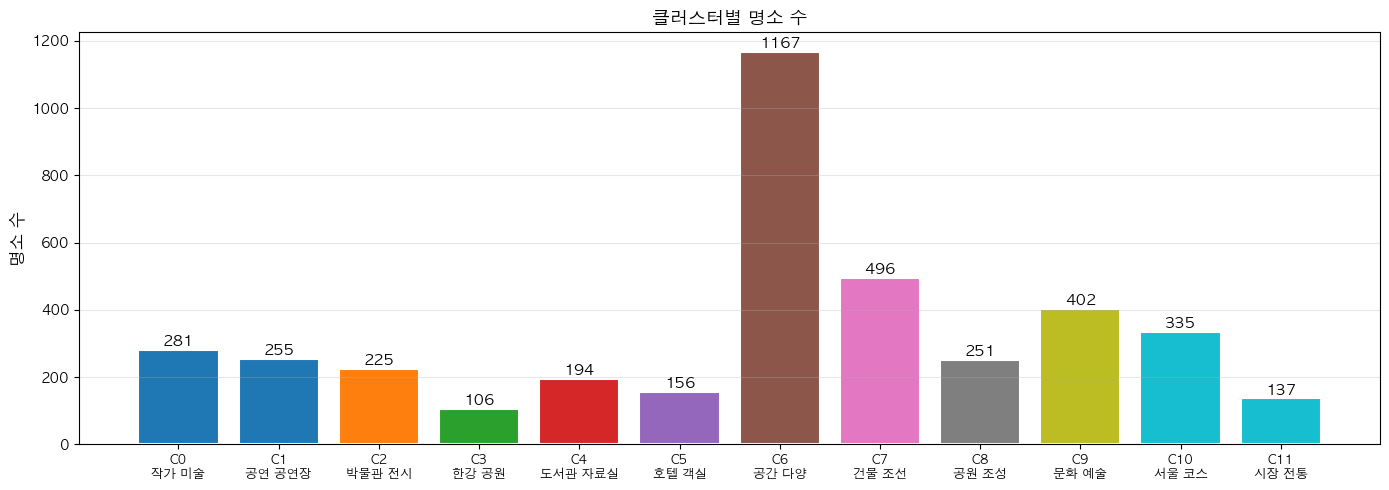

In [13]:
# 클러스터별 명소 수 막대그래프
cluster_sizes = df['cluster'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(range(best_k), cluster_sizes.values, color=colors, edgecolor='white', linewidth=1.5)

for bar, size in zip(bars, cluster_sizes.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(size), ha='center', va='bottom', fontsize=11, fontweight='bold')

x_labels = [f'C{i}\n{" ".join(cluster_keywords[i][:2])}' for i in range(best_k)]
ax.set_xticks(range(best_k))
ax.set_xticklabels(x_labels, fontsize=9)
ax.set_ylabel('명소 수', fontsize=12)
ax.set_title('클러스터별 명소 수', fontsize=13)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 9. 결과 저장

In [14]:
# 전체 데이터에 cluster 컬럼 추가해서 저장
df.to_excel('관광데이터_클러스터링_결과.xlsx', index=False)

# 클러스터 요약 저장
summary = []
for i in range(best_k):
    items = df[df['cluster'] == i]['name'].tolist()
    summary.append({
        'cluster': i,
        'count': len(items),
        'top_keywords': ' | '.join(cluster_keywords[i][:5]),
        'places_sample': ', '.join(items[:10])
    })

summary_df = pd.DataFrame(summary)
summary_df.to_excel('클러스터_요약.xlsx', index=False)
print('저장 완료!')
summary_df

저장 완료!


,cluster,count,top_keywords,places_sample
0,0,281,작가 | 미술 | 갤러리 | 전시 | 작품,"서울시립미술관 (서소문본관), 리움 미술관, 송은(SONGEUN), 갤러리 현대, ..."
1,1,255,공연 | 공연장 | 극장 | 무대 | 공간,"소극장 산울림, 씨어터쿰, 노원문화예술회관, 동숭무대소극장, 한국방송회관 코바코홀,..."
2,2,225,박물관 | 전시 | 역사 | 유물 | 문화,"국립중앙박물관, 한국가구박물관, 대한민국역사박물관, 서울역사박물관, 서대문자연사박물..."
3,3,106,한강 | 공원 | 서울 | 조명 | 공간,"한강 이랜드크루즈, 세빛섬, 한강버스, 풍납토성, 살곶이다리（전곶교）, 잠실대교, ..."
4,4,194,도서관 | 자료실 | 독서 | 정보 | 문화,"별마당 도서관, 서울도서관 (옛 서울시청사), 정독도서관, 국립중앙도서관, 김근태기..."
5,5,156,호텔 | 객실 | 비즈니스 | 서비스 | 서울,"서울중앙우체국, 수락휴 트리하우스, 포포인츠 바이 쉐라톤 서울 구로, 롯데호텔 월드..."
6,6,1167,공간 | 다양 | 체험 | 운영 | 서울,"익선동 한옥거리, 롯데월드타워, 63스퀘어, 북촌한옥마을, 서대문형무소역사관, 전쟁..."
7,7,496,건물 | 조선 | 사용 | 건축 | 지붕,"경복궁, 창덕궁, 종묘, 덕수궁, 창경궁, 국회의사당, 정릉, 숭례문(남대문), 창..."
8,8,251,공원 | 조성 | 자연 | 생태 | 시설,"선정릉(선릉), 도산공원, 백범광장공원, 허준근린공원, 사직단, 일자산허브천문공원,..."
9,9,402,문화 | 예술 | 공간 | 지역 | 다양,"예술의전당 한가람미술관, 문화역서울 284, 국립현대미술관 서울관, 1898 명동성..."


In [21]:
best_k = 18  # 직접 고정

km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['cluster'] = km_final.fit_predict(X)

feature_names = vectorizer.get_feature_names_out()
cluster_keywords = {}

for i in range(best_k):
    center = km_final.cluster_centers_[i]
    top_idx = center.argsort()[-10:][::-1]
    keywords = [feature_names[j] for j in top_idx]
    cluster_keywords[i] = keywords
    items = df[df['cluster'] == i]['name'].tolist()
    print(f'\n[클러스터 {i}] ({len(items)}개)')
    print(f'  키워드: {" | ".join(keywords[:5])}')
    print(f'  명소: {", ".join(items[:5])}')


[클러스터 0] (249개)
  키워드: 공연 | 공연장 | 극장 | 무대 | 공간
  명소: 소극장 산울림, 씨어터쿰, 노원문화예술회관, 동숭무대소극장, 한국방송회관 코바코홀

[클러스터 1] (232개)
  키워드: 건물 | 사용 | 건축 | 지붕 | 양식
  명소: 덕수궁, 국회의사당, 숭례문(남대문), 약현성당, 갤러리 학고재

[클러스터 2] (238개)
  키워드: 공원 | 조성 | 자연 | 시설 | 생태
  명소: 선정릉(선릉), 도산공원, 백범광장공원, 허준근린공원, 사직단

[클러스터 3] (214개)
  키워드: 예술 | 문화 | 공간 | 전시 | 예술가
  명소: 국립현대미술관 서울관, SJ쿤스트할레, 종이나라박물관, 신당창작아케이드, 스페이스 씨

[클러스터 4] (422개)
  키워드: 공간 | 체험 | 다양 | 전시 | 문화
  명소: 동대문디자인플라자 (DDP), 예술의전당 한가람미술관, 문화역서울 284, 1898 명동성당, 코엑스

[클러스터 5] (137개)
  키워드: 시장 | 전통 | 골목 | 판매 | 다양
  명소: 국립현대미술관 덕수궁관, 효자베이커리, 손맛김밥, 더 윌로, 역사풍속화가 혜촌 김학수의 칠패시와 경동상회

[클러스터 6] (200개)
  키워드: 문화 | 지역 | 운영 | 구민 | 다양
  명소: 국립한글박물관, KCDF갤러리, 한지가헌, 주한독일문화원, 주한영국문화원

[클러스터 7] (288개)
  키워드: 조선 | 시대 | 조성 | 자리 | 고종
  명소: 경복궁, 창덕궁, 종묘, 국립중앙박물관, 덕수궁돌담길

[클러스터 8] (203개)
  키워드: 박물관 | 전시 | 유물 | 문화 | 역사
  명소: 한국가구박물관, 대한민국역사박물관, 서울역사박물관, 서대문자연사박물관, 피규어뮤지엄W

[클러스터 9] (817개)
  키워드: 서울 | 한국 | 거리 | 전통 | 가게
  명소: 남산서울타워, 익선동 한옥거리, 롯데월드타워, 63스퀘어, 북촌한옥마을

[클러스터 10] (198개)
  키워드: 작가

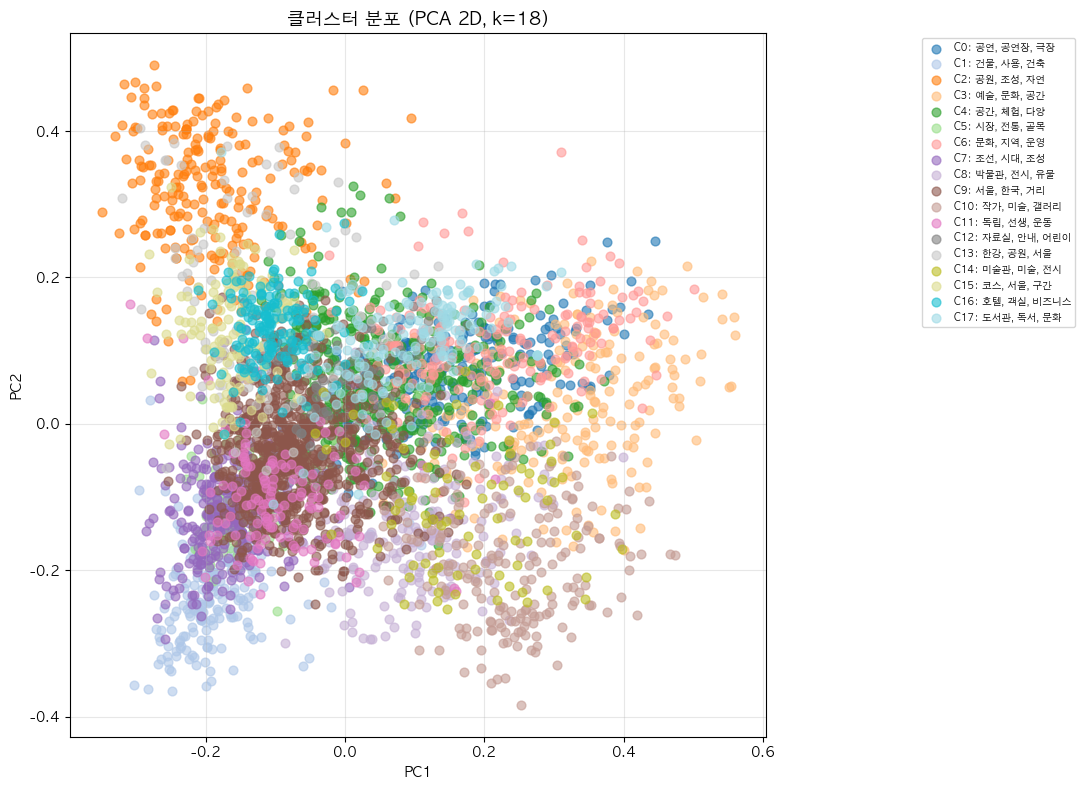

In [22]:
# PCA로 2D 축소 후 클러스터 분포 시각화
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X.toarray())

colors = plt.cm.tab20(np.linspace(0, 1, best_k))

plt.figure(figsize=(12, 8))
for i in range(best_k):
    mask = df['cluster'] == i
    top3 = ', '.join(cluster_keywords[i][:3])
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                c=[colors[i]], label=f'C{i}: {top3}',
                alpha=0.6, s=40)

plt.title(f'클러스터 분포 (PCA 2D, k={best_k})', fontsize=13)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(loc='upper right', fontsize=7, bbox_to_anchor=(1.45, 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

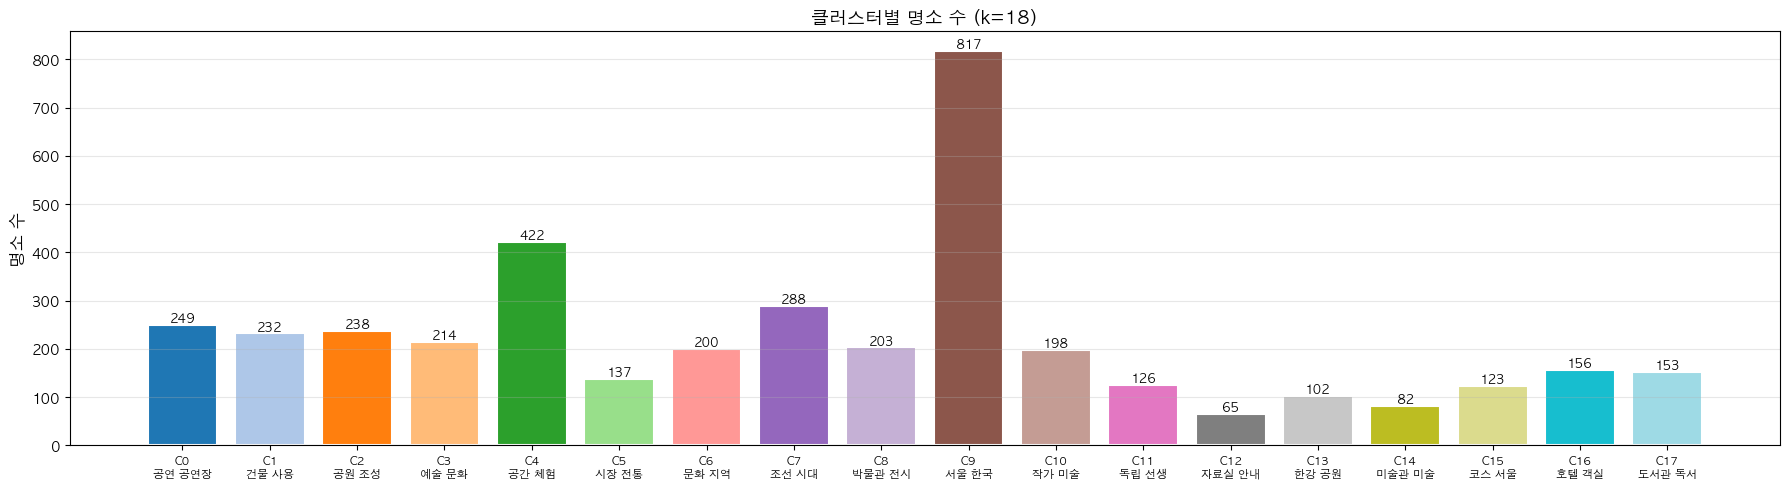

In [23]:
colors = plt.cm.tab20(np.linspace(0, 1, best_k))

cluster_sizes = df['cluster'].value_counts().sort_index()
cluster_ids = cluster_sizes.index.tolist()  # 실제 존재하는 클러스터 번호만

fig, ax = plt.subplots(figsize=(18, 5))
bar_colors = [colors[i] for i in cluster_ids]
bars = ax.bar(range(len(cluster_ids)), cluster_sizes.values, color=bar_colors, edgecolor='white', linewidth=1.5)

for bar, size in zip(bars, cluster_sizes.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(size), ha='center', va='bottom', fontsize=9, fontweight='bold')

x_labels = [f'C{i}\n{" ".join(cluster_keywords[i][:2])}' for i in cluster_ids]
ax.set_xticks(range(len(cluster_ids)))
ax.set_xticklabels(x_labels, fontsize=8)
ax.set_ylabel('명소 수', fontsize=12)
ax.set_title(f'클러스터별 명소 수 (k={best_k})', fontsize=13)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()